<a href="https://colab.research.google.com/github/Ann-tech2025/Robotics-Final-Year-Project/blob/main/CRNN_%2Battention_speech_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uwrfkaggler_ravdess_emotional_speech_audio_path = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
ejlok1_toronto_emotional_speech_set_tess_path = kagglehub.dataset_download('ejlok1/toronto-emotional-speech-set-tess')
ejlok1_cremad_path = kagglehub.dataset_download('ejlok1/cremad')
ejlok1_surrey_audiovisual_expressed_emotion_savee_path = kagglehub.dataset_download('ejlok1/surrey-audiovisual-expressed-emotion-savee')

print('Data source import complete.')


#

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Reshape, Bidirectional, LSTM,
    Dense, Attention
)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import os
import librosa
import numpy as np
import seaborn as sns
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Reshape, Bidirectional, LSTM,
    Dense, Dropout
)
import numpy as np
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical


In [ ]:
SAMPLE_RATE = 22050
MFCC_COUNT = 40
MAX_LEN = 174
NUM_CLASSES = 5   # angry, happy, sad, neutral, fear
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=MFCC_COUNT
    )

    mfcc = librosa.util.fix_length(mfcc, size=MAX_LEN, axis=1)
    return mfcc
emotion_map = {
    "angry": 0,
    "happy": 1,
    "sad": 2,
    "neutral": 3,
    "fear": 4
}

X = []
y = []
ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"

rav_map = {
    5:0, 3:1, 4:2, 1:3, 6:4
}

for folder in os.listdir(ravdess):
    for file in os.listdir(ravdess + folder):
        parts = file.split("-")
        emotion = int(parts[2])

        if emotion in rav_map:
            mfcc = extract_mfcc(ravdess + folder + "/" + file)
            X.append(mfcc)
            y.append(rav_map[emotion])

tess_path = "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

for folder in os.listdir(tess_path):
    emotion = folder.split("_")[-1].lower()

    if emotion in emotion_map:
        for file in os.listdir(os.path.join(tess_path, folder)):
            mfcc = extract_mfcc(os.path.join(tess_path, folder, file))
            X.append(mfcc)
            y.append(emotion_map[emotion])
crema_path = "/kaggle/input/cremad/AudioWAV"

crema_map = {
    "ANG":0, "HAP":1, "SAD":2, "NEU":3, "FEA":4
}

for file in os.listdir(crema_path):
    parts = file.split("_")
    emo = parts[2]

    if emo in crema_map:
        mfcc = extract_mfcc(os.path.join(crema_path, file))
        X.append(mfcc)
        y.append(crema_map[emo])
savee_path = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL"

savee_map = {
    "_a":0, "_h":1, "_sa":2, "_n":3, "_f":4
}

for file in os.listdir(savee_path):
    fname = file.lower()
    for k in savee_map:
        if k in fname:
            mfcc = extract_mfcc(os.path.join(savee_path, file))
            X.append(mfcc)
            y.append(savee_map[k])



In [ ]:
X = np.array(X)
y = np.array(y)

# add channel dimension
X = X[..., np.newaxis]

y_cat = to_categorical(y, NUM_CLASSES)


In [ ]:
# X  -> MFCC features (samples, 40, time)
# y_cat -> one-hot labels
# y -> class labels (0–4)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)
y_train_labels = np.argmax(y_train, axis=1)


# Add channel dimension
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

num_classes = y_train.shape[1]
input_shape = (40, X_train_cnn.shape[2], 1)

print(X_train_cnn.shape, X_test_cnn.shape)


(7516, 40, 174, 1, 1) (1879, 40, 174, 1, 1)


In [ ]:
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv2D, MaxPooling2D,
    BatchNormalization, Reshape, LSTM, Layer
)
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)


In [ ]:
def build_crnn_attention(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    # reshape for RNN
    shape = x.shape
    x = Reshape((shape[2], shape[1]*shape[3]))(x)

    x = LSTM(128, return_sequences=True)(x)
    x = Attention()(x)

    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_labels), 1):

    print(f"\n🚀 Fold {fold}")

    tf.keras.backend.clear_session()

    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    model = build_crnn_attention(X.shape[1:], NUM_CLASSES)

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        verbose=1
    )



🚀 Fold 1
Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 64s 324ms/step - accuracy: 0.3833 - loss: 1.4058 - val_accuracy: 0.4787 - val_loss: 1.3185
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 308ms/step - accuracy: 0.5694 - loss: 1.0419 - val_accuracy: 0.5798 - val_loss: 0.9890
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 309ms/step - accuracy: 0.6317 - loss: 0.9129 - val_accuracy: 0.6243 - val_loss: 0.9173
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 60s 321ms/step - accuracy: 0.6792 - loss: 0.8092 - val_accuracy: 0.6396 - val_loss: 0.8772
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 308ms/step - accuracy: 0.7034 - loss: 0.7561 - val_accuracy: 0.6316 - val_loss: 0.8923
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 60s 321ms/step - accuracy: 0.7403 - loss: 0.6696 - val_accuracy: 0.6616 - val_loss: 0.8584
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 61s 324ms/step - accuracy: 0.7750 - loss: 0.5799 - val_accuracy: 0.6443 - val_loss: 0.9640
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 310ms/step - accuracy: 0.8013

In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"✅ Fold {fold} validation accuracy: {val_acc:.4f}")

    fold_accuracies.append(val_acc)

print("\nAverage CV Accuracy:", np.mean(fold_accuracies))

IndentationError: unexpected indent (2750368942.py, line 2)

In [ ]:
tf.keras.backend.clear_session()

final_model = build_crnn_attention(X.shape[1:], NUM_CLASSES)

history = final_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 98s 443ms/step - accuracy: 0.3951 - loss: 1.3871 - val_accuracy: 0.5598 - val_loss: 1.0935
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 79s 373ms/step - accuracy: 0.5820 - loss: 1.0135 - val_accuracy: 0.6316 - val_loss: 0.9300
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 64s 300ms/step - accuracy: 0.6443 - loss: 0.8826 - val_accuracy: 0.6343 - val_loss: 0.8770
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step - accuracy: 0.6839 - loss: 0.7987 - val_accuracy: 0.6582 - val_loss: 0.8580
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 60s 282ms/step - accuracy: 0.7114 - loss: 0.7345 - val_accuracy: 0.6463 - val_loss: 0.8821
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 59s 276ms/step - accuracy: 0.7460 - loss: 0.6435 - val_accuracy: 0.6436 - val_loss: 0.8690
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step - accuracy: 0.7737 - loss: 0.5745 - val_accuracy: 0.6702 - val_loss: 0.8392
Epoch 8/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 60s 281ms/step - accuracy: 0.8089 - loss: 0

In [ ]:

test_loss, test_acc = final_model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6479 - loss: 1.6208
Test Accuracy: 0.6615220904350281


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step

✅ Classification Report:

              precision    recall  f1-score   support

       angry       0.79      0.74      0.76       385
       happy       0.61      0.62      0.61       384
         sad       0.63      0.71      0.67       385
     neutral       0.63      0.70      0.66       340
        fear       0.66      0.55      0.60       385

    accuracy                           0.66      1879
   macro avg       0.66      0.66      0.66      1879
weighted avg       0.66      0.66      0.66      1879



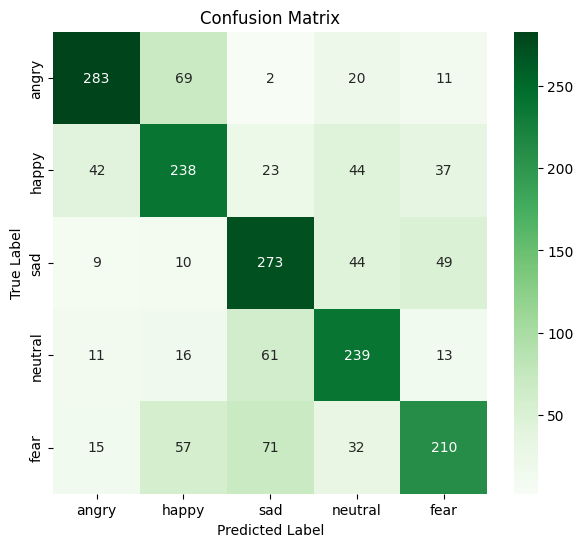

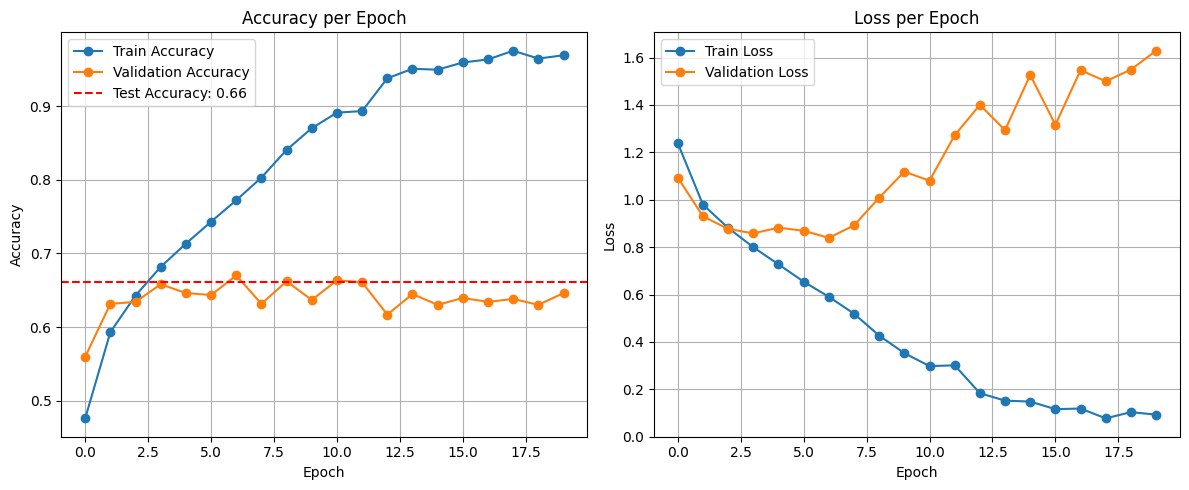

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(final_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n✅ Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["angry","happy","sad","neutral","fear"]
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=["angry","happy","sad","neutral","fear"],
    yticklabels=["angry","happy","sad","neutral","fear"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axhline(test_acc, color='red', linestyle='--', label=f'Test Accuracy: {test_acc:.2f}')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Save model
final_model.save("crnn_attention_model.h5")
print("✅ Model saved as crnn_attention_model.h5")
